## Import thư viện

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_column',None)
from sklearn.model_selection import train_test_split,GridSearchCV 
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
import pickle

## Load dữ liệu

In [ ]:
data = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Bước 2: Xử lý dữ liệu
---

### Quan sát và khám phá tập dữ liệu
---

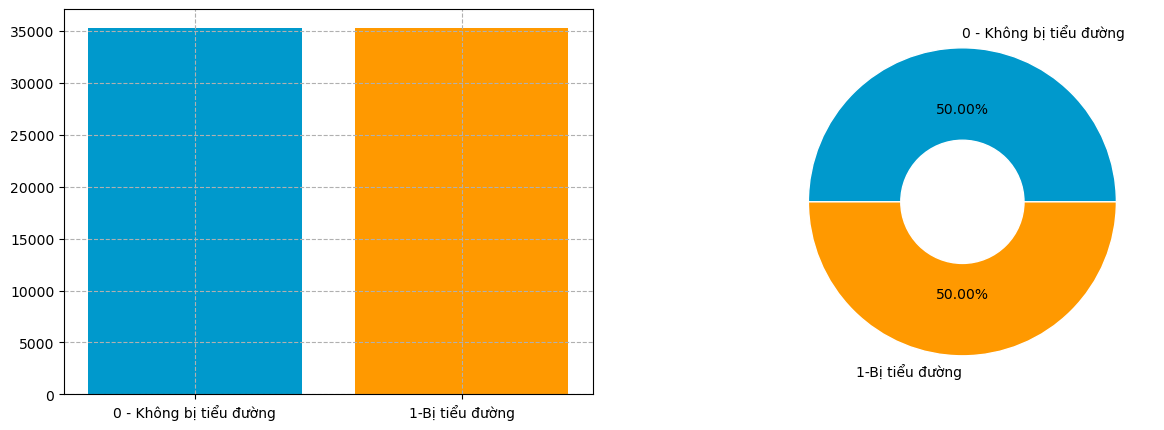

In [ ]:
#Thống kê số lượng bệnh nhân bị bệnh và không bị bệnh (Đánh giá mức độ cân bằng dữ liệu)
kq = data['Diabetes_binary'].value_counts()
lb = ['0 - Không bị tiểu đường','1-Bị tiểu đường']

#----------------------------------------------
#trực quan hóa số liệu
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))

#Vẽ biểu đồ cột thể hiện số lượng hồ sơ bị bệnh - không bị bệnh
plt.subplot(1,2,1) 
plt.bar(lb,kq.values, color=['#0099CC','#FF9900'])
plt.grid(ls='--')

#Vẽ biểu đồ tròn thể hiện tỷ lệ % hồ sơ bị bệnh - ko bị bệnh
plt.subplot(1,2,2)
plt.pie(kq.values, labels=lb, colors=['#0099CC','#FF9900'],
        autopct='%.2f%%', wedgeprops=dict(width=0.6,edgecolor='w'))

plt.show()

<b>Nhận xét tập dữ liệu cân bằng giữa hai lớp đầu ra: 
+ <b>Lớp 0: Không bị bệnh ~50% <br>
+ <b>Lớp 1: bị bệnh ~ 50% <br>
=> Dữ liệu cân bằng --> Không cần xử lý cân bằng dữ liệu. </b>

### Loại bỏ các giá trị trùng lặp (Duplicates)

In [10]:
# Kiểm tra các giá trị trùng lăp
# In ra tổng các hàng trong dữ liệu
print('Tổng số hàng:', data.shape[0])
print('Các giá trị trùng lăp:', data.duplicated().sum())

Tổng số hàng: 70692
Các giá trị trùng lăp: 1635


#### Nhận xét: Có thể thấy dữ liệu đang có 1635 hàng trùng lặp nên tiến hành xóa các giá trị trùng lặp để tránh ảnh hướng xấu đến mô hình

In [12]:
# Tìm giá trị trùng lặp
duplicates = data[data.duplicated(keep=False)]
print(duplicates)

       Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
4                  0.0     0.0       0.0        1.0  29.0     1.0     0.0   
12                 0.0     1.0       1.0        1.0  27.0     0.0     0.0   
20                 0.0     0.0       0.0        1.0  22.0     0.0     0.0   
58                 0.0     0.0       0.0        1.0  23.0     1.0     0.0   
86                 0.0     0.0       0.0        1.0  33.0     0.0     0.0   
...                ...     ...       ...        ...   ...     ...     ...   
69865              1.0     1.0       1.0        1.0  27.0     1.0     0.0   
69939              1.0     1.0       1.0        1.0  27.0     1.0     0.0   
70305              1.0     1.0       0.0        1.0  30.0     0.0     0.0   
70591              1.0     1.0       1.0        1.0  30.0     0.0     0.0   
70663              1.0     1.0       1.0        1.0  33.0     0.0     0.0   

       HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsu

In [13]:
# Xóa giá trị trùng lặp
data.drop_duplicates(inplace=True) 
print('Tổng số hàng còn lại sau khi xóa: ', data.shape[0])

Tổng số hàng còn lại sau khi xóa:  69057


### Phát hiện và xử lý dữ liệu thiếu trong Dataset
---

In [15]:
#Kiểm tra dữ liệu thiếu trong Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69057 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       69057 non-null  float64
 1   HighBP                69057 non-null  float64
 2   HighChol              69057 non-null  float64
 3   CholCheck             69057 non-null  float64
 4   BMI                   69057 non-null  float64
 5   Smoker                69057 non-null  float64
 6   Stroke                69057 non-null  float64
 7   HeartDiseaseorAttack  69057 non-null  float64
 8   PhysActivity          69057 non-null  float64
 9   Fruits                69057 non-null  float64
 10  Veggies               69057 non-null  float64
 11  HvyAlcoholConsump     69057 non-null  float64
 12  AnyHealthcare         69057 non-null  float64
 13  NoDocbcCost           69057 non-null  float64
 14  GenHlth               69057 non-null  float64
 15  MentHlth              69

#### Nhận xét: Kiểm tra thông tin của bộ dữ liệu có thế thấy các hàng không có giá trị thiếu và kiểu dữ liệu của bộ dữ liệu cũng đã đồng nhất

### Kiểm tra tính đồng nhất của dữ liệu
---

In [18]:
# Kiểm tra tính đồng nhất của các cột
unique_counts = data.nunique()
print(unique_counts)

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64


#### Nhận xét: Kiểm tra tính đồng nhất của các cột dữ liệu thì có thể thấy dữ liệu đã đúng với mô tả không có cột nào chưa đồng nhất 

### Xử lý ngoại lai
---

array([[<Axes: title={'center': 'Diabetes_binary'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title=

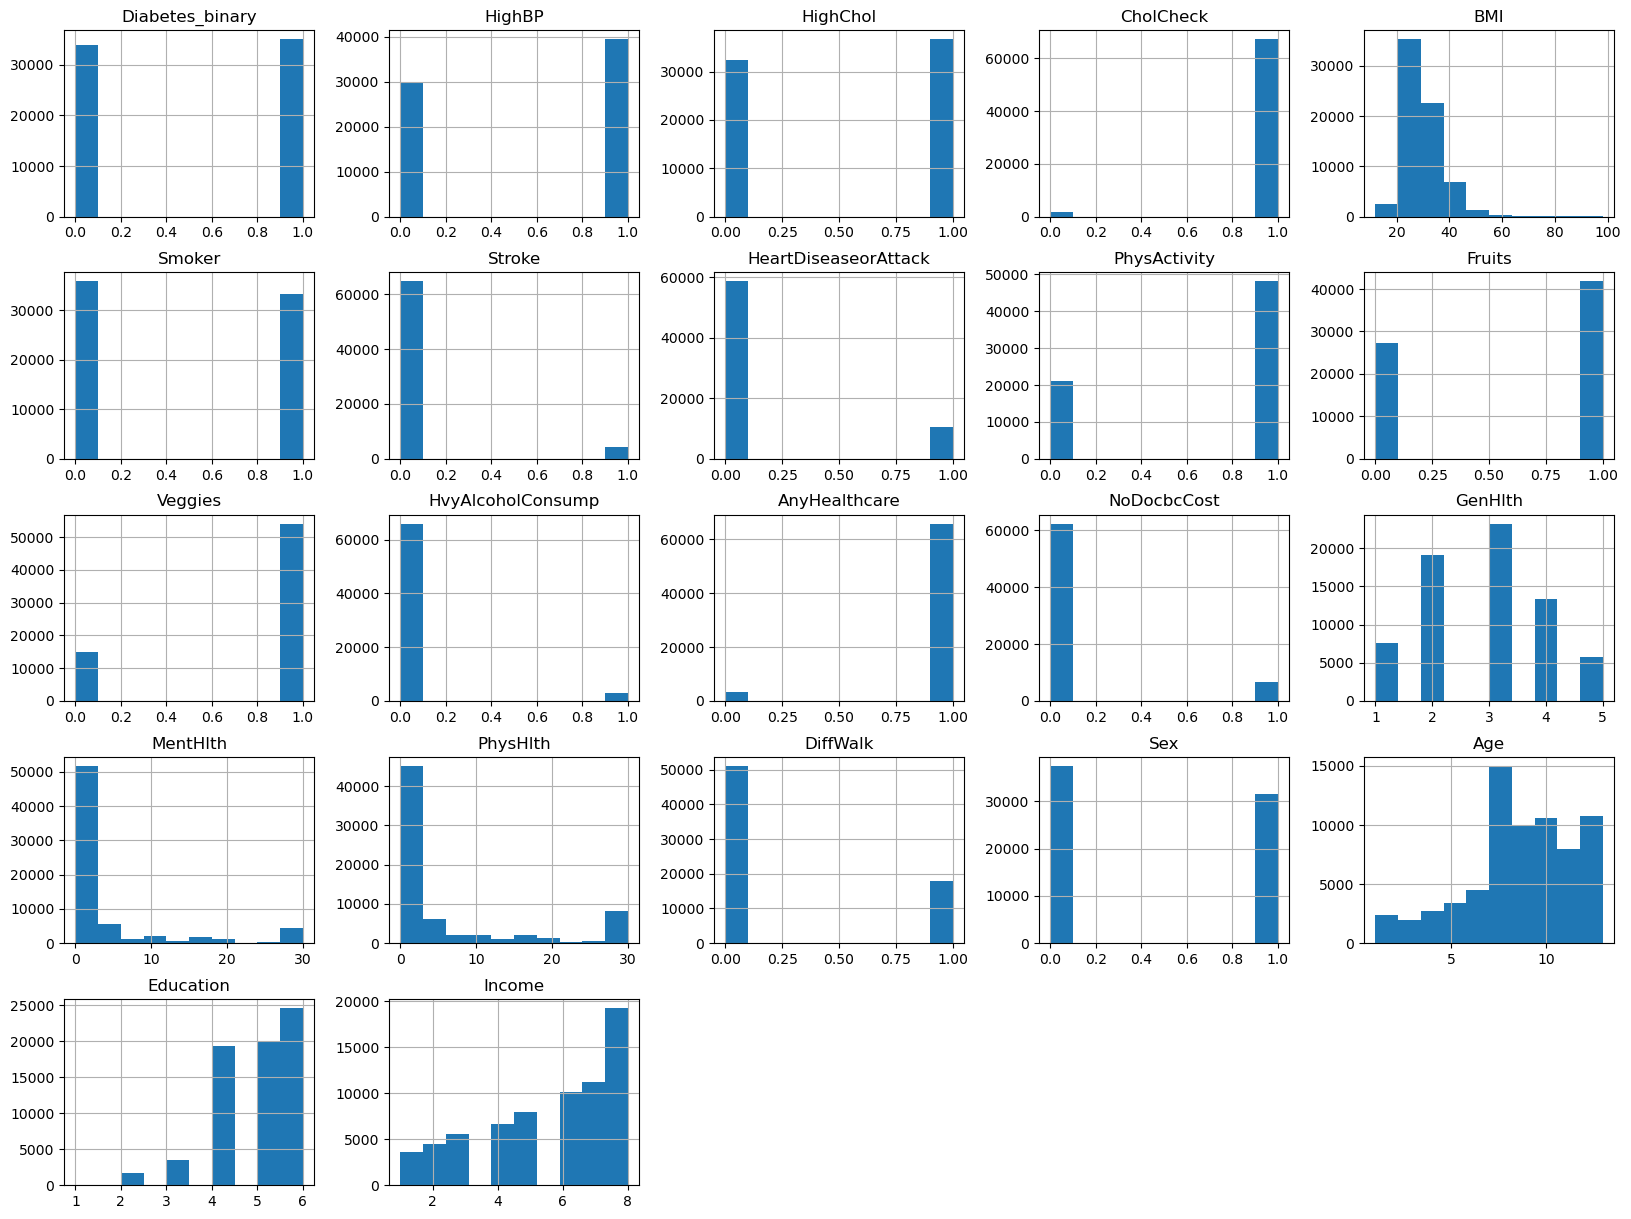

In [21]:
data.hist(figsize=(20, 15))

#### Nhận xét: Kiểm tra phân phối của các cột dữ liệu có thể thấy rằng một số cột đang có phân phối dữ liệu không đều và cột BMI đang có dấu hiệu bất thường

In [23]:
data.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000
mean,0.508232,0.571224,0.531329,0.974803,29.955834,0.481935,0.063643,0.150875,0.696483,0.605659,0.784120,0.043515,0.953908,0.096138,2.863692,3.840103,5.945306,0.258612,0.456464,8.604037,4.900285,5.651332
std,0.499936,0.494905,0.499021,0.156723,7.147972,0.499677,0.244118,0.357930,0.459780,0.488712,0.411434,0.204014,0.209687,0.294782,1.107950,8.231164,10.139113,0.437875,0.498105,2.858284,1.029338,2.175608
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,1.000000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,3.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


#### Nhận xét: Có thể thấy rằng cột BMI đang có giá trị ngoại lai 

<Axes: ylabel='Count'>

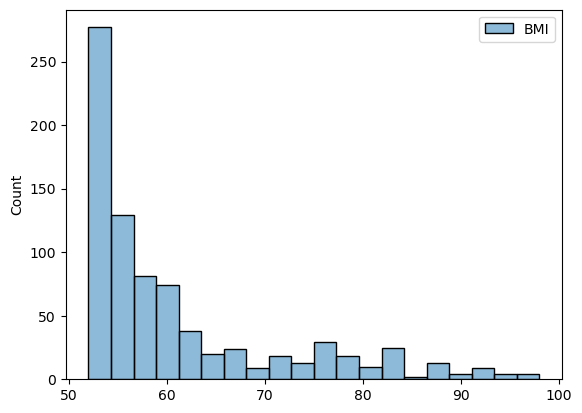

In [25]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán z-score cho cột BMI
data['z_score_bmi'] = stats.zscore(data['BMI'], ddof=1)

# Lọc ra các giá trị ngoại lai trong cột BMI
data_outliers= data[(data['z_score_bmi'] > 3) | (data['z_score_bmi'] < -3)][['z_score_bmi']]

# In ra giá trị của cột BMI của các giá trị ngoại lai
sns.histplot(data[(data['z_score_bmi'] > 3) | (data['z_score_bmi'] < -3)][['BMI']])


In [26]:
print(f"Số lượng giá trị ngoại lai: {len(data_outliers)}")
outlier_ratio = len(data_outliers) / 69057
print(f"Tỷ lệ giá trị ngoại lai: {outlier_ratio:.2%}")

Số lượng giá trị ngoại lai: 801
Tỷ lệ giá trị ngoại lai: 1.16%


#### Nhận xét: Trong thực tế mặc dù rất hiếm nhưng vẫn có người BMI từ 50 - 100, các giá trị ngoại lai cũng chỉ chiểm hơn 1% trong cột dữ liệu nên sẽ không ảnh hưởng nhiều đến mô hình. Ngoài ra việc giữ lại những chỉ số này cũng làm đa dạng hơn cho mô hình phản ánh đúng với thực tế

In [28]:
data.drop(columns=['z_score_bmi'], inplace=True)

#### Nhận xét: Xóa cột z_score_bmi sau khi đã xong bước kiểm tra ngoại lai

## Bước 3: Feature Engineering
---

### Feature Creation
---

In [32]:
data_copy = data.copy()

data_copy['BMI_Age'] = data_copy['BMI'] * data_copy['Age']
data_copy['GenHlth_PhysActivity'] = data_copy['GenHlth'] * data_copy['PhysActivity']
data_copy['Ment_Phys_Health_Score'] = data_copy['MentHlth'] + data_copy['PhysHlth']

data_copy.drop(columns=['BMI', 'Age', 'GenHlth', 'PhysActivity', 'MentHlth', 'PhysHlth'], inplace=True)

#### Nhận xét:
##### BMI × Age: Biến số biểu thị ảnh hưởng của chỉ số khối cơ thể theo độ tuổi.<br>
##### GenHlth × PhysActivity: Mức độ sức khỏe chung kết hợp với mức độ vận động thể chất.<br>
##### Ment_Phys_Health_Score: Tổng hợp sức khỏe tâm lý và thể chất.<br>
##### Copy một biến lưu dữ liệu mới để giữ lại các biến đặc trưng của tệp dữ liệu cũ


### Chia tập dữ liệu Train - Test

In [35]:
X_old = data.drop('Diabetes_binary', axis=1)
y_old = data['Diabetes_binary']

X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(X_old, y_old, test_size=0.3, random_state=42)

X_new = data_copy.drop('Diabetes_binary', axis=1)
y_new = data_copy['Diabetes_binary']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

#### Chia tệp dữ liệu cũ và tệp dữ liệu mới khi thêm biến mới để thử nghiệm 
---

In [37]:
# Huấn luyện mô hình trước khi tạo biến mới
model_old = RandomForestClassifier(random_state=42)
model_old.fit(X_train_old, y_train_old)
y_pred_old = model_old.predict(X_test_old)

# Huấn luyện mô hình sau khi ta đã tạo biến mới
model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train_new)
y_pred_new = model_new.predict(X_test_new)

# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_all = recall_score(y_test_old, y_pred_old)
precision_all = precision_score(y_test_old, y_pred_old)
f1_all = f1_score(y_test_old, y_pred_old)
accuracy_all = accuracy_score(y_test_old, y_pred_old)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_selected = recall_score(y_test_new, y_pred_new)
precision_selected = precision_score(y_test_new, y_pred_new)
f1_selected = f1_score(y_test_new, y_pred_new)
accuracy_selected = accuracy_score(y_test_new, y_pred_new)

# So sánh kết quả
comparison = pd.DataFrame({
    'Model': ['OLD', 'NEW'],
    'Recall': [recall_all, recall_selected],
    'Precision': [precision_all, precision_selected],
    'F1 Score': [f1_all, f1_selected],
    'Accuracy': [accuracy_all, accuracy_selected]
})

print(comparison)

  Model    Recall  Precision  F1 Score  Accuracy
0   OLD  0.773448   0.726684  0.749337  0.735303
1   NEW  0.754954   0.710379  0.731988  0.717202


#### Nhận xét: Nhìn vào các chỉ só có thể thấy rằng các biến mới không mang lại nhiều lợi ích cho mô hình nên sẽ vẫn giữ các biến như ban đầu

### Feature Transformation
---

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler_stand = StandardScaler()
data[['BMI']] = scaler_stand.fit_transform(data[['BMI']])

scaler_nomal = MinMaxScaler()
data[['HighBP', 'GenHlth', 'Age', 'Education', 'Income']] = scaler_nomal.fit_transform(data[['HighBP', 'GenHlth', 'Age', 'Education', 'Income']])

data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,-0.553424,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.50,5.0,30.0,0.0,1.0,0.250000,1.0,1.0
1,0.0,1.0,1.0,1.0,-0.553424,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.50,0.0,0.0,0.0,1.0,0.916667,1.0,1.0
2,0.0,0.0,0.0,1.0,-0.553424,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.00,0.0,10.0,0.0,1.0,1.000000,1.0,1.0
3,0.0,1.0,1.0,1.0,-0.273623,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.50,0.0,3.0,0.0,1.0,0.833333,1.0,1.0
4,0.0,0.0,0.0,1.0,-0.133722,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.583333,0.8,1.0


#### Nhận xét: Ở đây chỉ duy nhất cột BMI có phân phối chuẩn còn lại các cột đều có phần phối không chuẩn vậy nên chỉ áp dụng StandardScaler cho cột BMI 

## Bước 4: Kiểm tra Overfiting và Underfiting của mô hình
---

### Chia lại tập dữ liệu theo tỷ lệ 3 test và 7 train 
---

In [44]:
X = data.drop('Diabetes_binary', axis=1)
y = data['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [45]:
# Khai báo model Random Forest, với các tham số mặc định
model_rf = RandomForestClassifier()

# Huấn luyện mô hình Random Forest trên dữ liệu huấn luyện
model_rf.fit(X_train,y_train)

# Dự đoán trên tập huấn luyện
y_pred_train = model_rf.predict(X_train)
y_pret_test = model_rf.predict(X_test)


### Chạy mô hình và kiểm tra kết quả trên cả 2 tập dữ liệu để đánh giá mô hình

---

Text(0.5, 1.0, 'Confusion Matrix Train ')

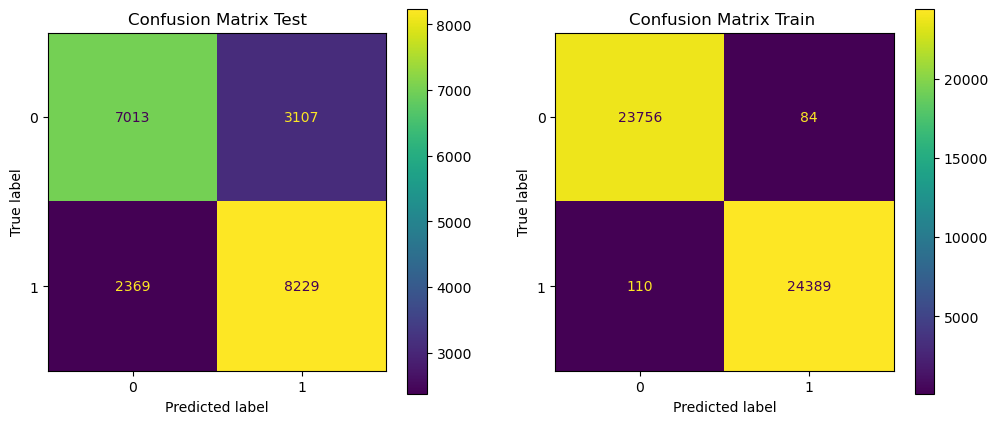

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for test set
cm = confusion_matrix(y_test, y_pret_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_test.plot(ax=axes[0])
axes[0].set_title('Confusion Matrix Test')

# Plot confusion matrix for train set
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axes[1])
axes[1].set_title('Confusion Matrix Train ')

In [48]:
# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_test = recall_score(y_test, y_pret_test)
precision_test = precision_score(y_test, y_pret_test)
f1_test = f1_score(y_test, y_pret_test)
accuracy_test = accuracy_score(y_test, y_pret_test)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_train = recall_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
f1_train= f1_score(y_train, y_pred_train)
accuracy_train = accuracy_score(y_train, y_pred_train)

# So sánh kết quả
comparison = pd.DataFrame({
    '': ['Test' , 'Train'],
    'Recall': [recall_test, recall_train],
    'Precision': [precision_test, precision_train],
    'F1 Score': [f1_test, f1_train],
    'Accuracy': [accuracy_test, accuracy_train]
})

print(comparison)

            Recall  Precision  F1 Score  Accuracy
0   Test  0.776467   0.725917  0.750342  0.735689
1  Train  0.995510   0.996568  0.996039  0.995987


<b> Nhận xét: Mô hình hiển thị sự overfitting khi accuracy trên tập huấn luyện cao đến 99.55%, trong khi trên tập kiểm tra chỉ đạt 73.78%. Điều này ám chỉ rằng mô hình có khả năng quá tinh chỉnh để phù hợp với dữ liệu huấn luyện mà không tổng quát hóa tốt trên dữ liệu mới. <br> <b>

<b>Precision trên tập huấn luyện (99.65%) cao hơn so với tập kiểm tra (71.95%), cho thấy mô hình có xu hướng dự đoán nhiều false positives trên tập kiểm tra. Ngược lại, recall trên tập kiểm tra (77.99%) cao hơn so với tập huấn luyện (99.44%), có thể mô hình tốt hơn trong việc dự đoán true positives trên tập kiểm tra. <br>

<b>Tuy nhiên, F1 Score trên tập kiểm tra (74.85%) thấp hơn so với tập huấn luyện (99.54%), có thể do sự kết hợp giữa precision và recall trên tập kiểm tra không tốt bằng trên tập huấn luyện. Sự chênh lệch lớn giữa các chỉ số đánh giá đề xuất cần phải cân nhắc điều chỉnh mô hình để cải thiện khả năng tổng quát hóa và tránh overfitting trên dữ liệu mới.</b>

## Bước 5: Hyperparameter Tuning 
---

### Grid Search CV

In [52]:
# Define the parameters for GridSearchCV
cv_params = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'min_samples_split': [2, 5, 10, 15, 20],
    'max_features': [2, 4],
    'n_estimators': [50, 100, 150],
    'criterion': ['gini', 'entropy']
}

# Define the scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Create a RandomForestClassifier instance
rf = RandomForestClassifier()

# Create the GridSearchCV object with n_jobs=-1 to use all available CPU cores
model_rf = GridSearchCV(rf, cv_params, cv=5, scoring=list(scoring), refit='f1', n_jobs=-1)

# Fit the model using GridSearchCV on the training data
model_rf.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print(model_rf.best_params_)
print(model_rf.best_estimator_)

{'criterion': 'gini', 'max_depth': 7, 'max_features': 4, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 100}
RandomForestClassifier(max_depth=7, max_features=4, min_samples_split=15)


<b> Nhận xét: Áp dụng GridSearchCV để tìm ra mô hình tốt nhất <br> Vì đề tài làm về y tế nên sẽ tìm ra mô hình có chỉ số F1 cao nhất thay vì độ chính xác.<br>
 Lý do chọn F1 là: <br> Mô hình sẽ cần chỉ số Recall cao để tránh bỏ sót các trường hợp bị tiểu đường nhưng mô hình lại dự đoán là không. <br> Mô hình cũng sẽ cần chỉ số Precision cao để tránh chẩn đoán nhầm khiến người kiểm tra hoang mang hoặc tốn tài nguyên điều trị sớm <br> F1 là chỉ số cân bằng giữa 2 chỉ số trên nên sẽ refit F1. <br> Trong bài toán y tế thì độ chính xác không đủ để đưa ra đánh giá chính xác cho người bệnh. </b>

### Feature Importance
---


<Axes: >

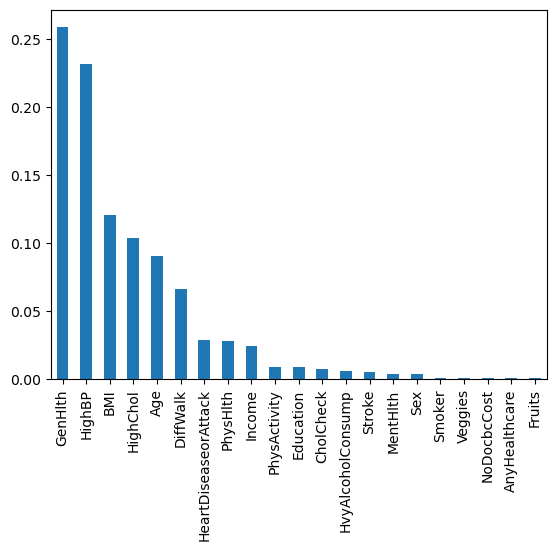

In [55]:
importances = model_rf.best_estimator_.feature_importances_

forest_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)

In [56]:
threshold = 0.01

# Lấy danh sách các cột cần giữ lại (những cột có importance >= threshold)
important_features = forest_importances[forest_importances >= threshold].index

# Lọc DataFrame để chỉ giữ lại các cột quan trọng
X_reduced = X[important_features]

# Hiển thị thông tin các cột còn lại
print(f"Các cột được giữ lại: {important_features.tolist()}")

Các cột được giữ lại: ['GenHlth', 'HighBP', 'BMI', 'HighChol', 'Age', 'DiffWalk', 'HeartDiseaseorAttack', 'PhysHlth', 'Income']


In [57]:
X = data[['HighBP', 'GenHlth', 'BMI', 'HighChol', 'Age', 'DiffWalk', 'HeartDiseaseorAttack', 'Income', 'PhysHlth', 'Education', 'CholCheck']]
y = data["Diabetes_binary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


#### Nhận xét: Dựa trên bảng thống kê mức quan trọng của các biến có thể chọn ra 11 biến tốt nhất để chạy lại mô hình

In [59]:
# Define the parameters for GridSearchCV
cv_params = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'min_samples_split': [2, 5, 10, 15, 20],
    'max_features': [2, 4],
    'n_estimators': [50, 100, 150],
    'criterion': ['gini', 'entropy']
}

# Define the scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Create a RandomForestClassifier instance
rf = RandomForestClassifier()

# Create the GridSearchCV object with n_jobs=-1 to use all available CPU cores
model_rf = GridSearchCV(rf, cv_params, cv=5, scoring=list(scoring), refit='f1', n_jobs=-1)

# Fit the model using GridSearchCV on the training data
model_rf.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print(model_rf.best_params_)
print(model_rf.best_estimator_)

{'criterion': 'gini', 'max_depth': 7, 'max_features': 4, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 150}
RandomForestClassifier(max_depth=7, max_features=4, min_samples_leaf=4,
                       min_samples_split=5, n_estimators=150)


In [ ]:
# Khai báo model Random Forest, thêm class_weight để xử lý mất cân bằng lớp
model_rf = RandomForestClassifier(
    max_depth=7,
    max_features=4,
    min_samples_leaf=2,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

# Huấn luyện mô hình Random Forest trên dữ liệu huấn luyện
model_rf.fit(X_train, y_train)

# Dự đoán trên tập huấn luyện
y_pred_train = model_rf.predict(X_train)
y_pret_test = model_rf.predict(X_test)

#### Nhận xét: Chạy lại mô hình với giá trị max_depth=7, max_features=4, min_samples_leaf=2,min_samples_split=20

Text(0.5, 1.0, 'Confusion Matrix Train ')

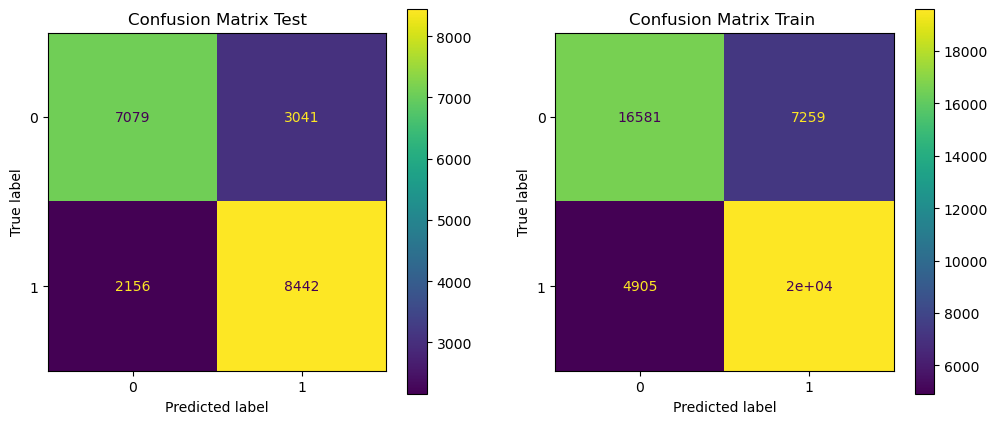

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for test set
cm = confusion_matrix(y_test, y_pret_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_test.plot(ax=axes[0])
axes[0].set_title('Confusion Matrix Test')

# Plot confusion matrix for train set
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axes[1])
axes[1].set_title('Confusion Matrix Train ')

In [63]:
# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_test = recall_score(y_test, y_pret_test)
precision_test = precision_score(y_test, y_pret_test)
f1_test = f1_score(y_test, y_pret_test)
accuracy_test = accuracy_score(y_test, y_pret_test)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_train = recall_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
f1_train= f1_score(y_train, y_pred_train)
accuracy_train = accuracy_score(y_train, y_pred_train)

# So sánh kết quả
comparison = pd.DataFrame({
    '': ['Test' , 'Train'],
    'Recall': [recall_test, recall_train],
    'Precision': [precision_test, precision_train],
    'F1 Score': [f1_test, f1_train],
    'Accuracy': [accuracy_test, accuracy_train]
})

print(comparison)

            Recall  Precision  F1 Score  Accuracy
0   Test  0.796565   0.735174  0.764639  0.749155
1  Train  0.799788   0.729676  0.763125  0.748361


#### Nhận xét: Nhìn vào biểu đồ và các chỉ số trên khi chạy mô hình trên 2 tập dữ liệu train và test có thể thấy được rằng mô hình đã không còn bị overfitting kèm theo đó các chỉ số đặc biệt là F1 cũng tăng lên so với mô hình ban đầu.

In [65]:
pickle.dump(model_rf, open("model_random_forest.pickle", "wb"))

In [67]:
with open("model_random_forest.pickle", 'rb') as to_read:
    model_rf = pickle.load(to_read)